In [357]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [358]:
!pip install opencv-python

In [359]:
# computer vision
import cv2
from google.colab.patches import cv2_imshow
from imutils.object_detection import non_max_suppression
from skimage.metrics import structural_similarity as ssim


import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

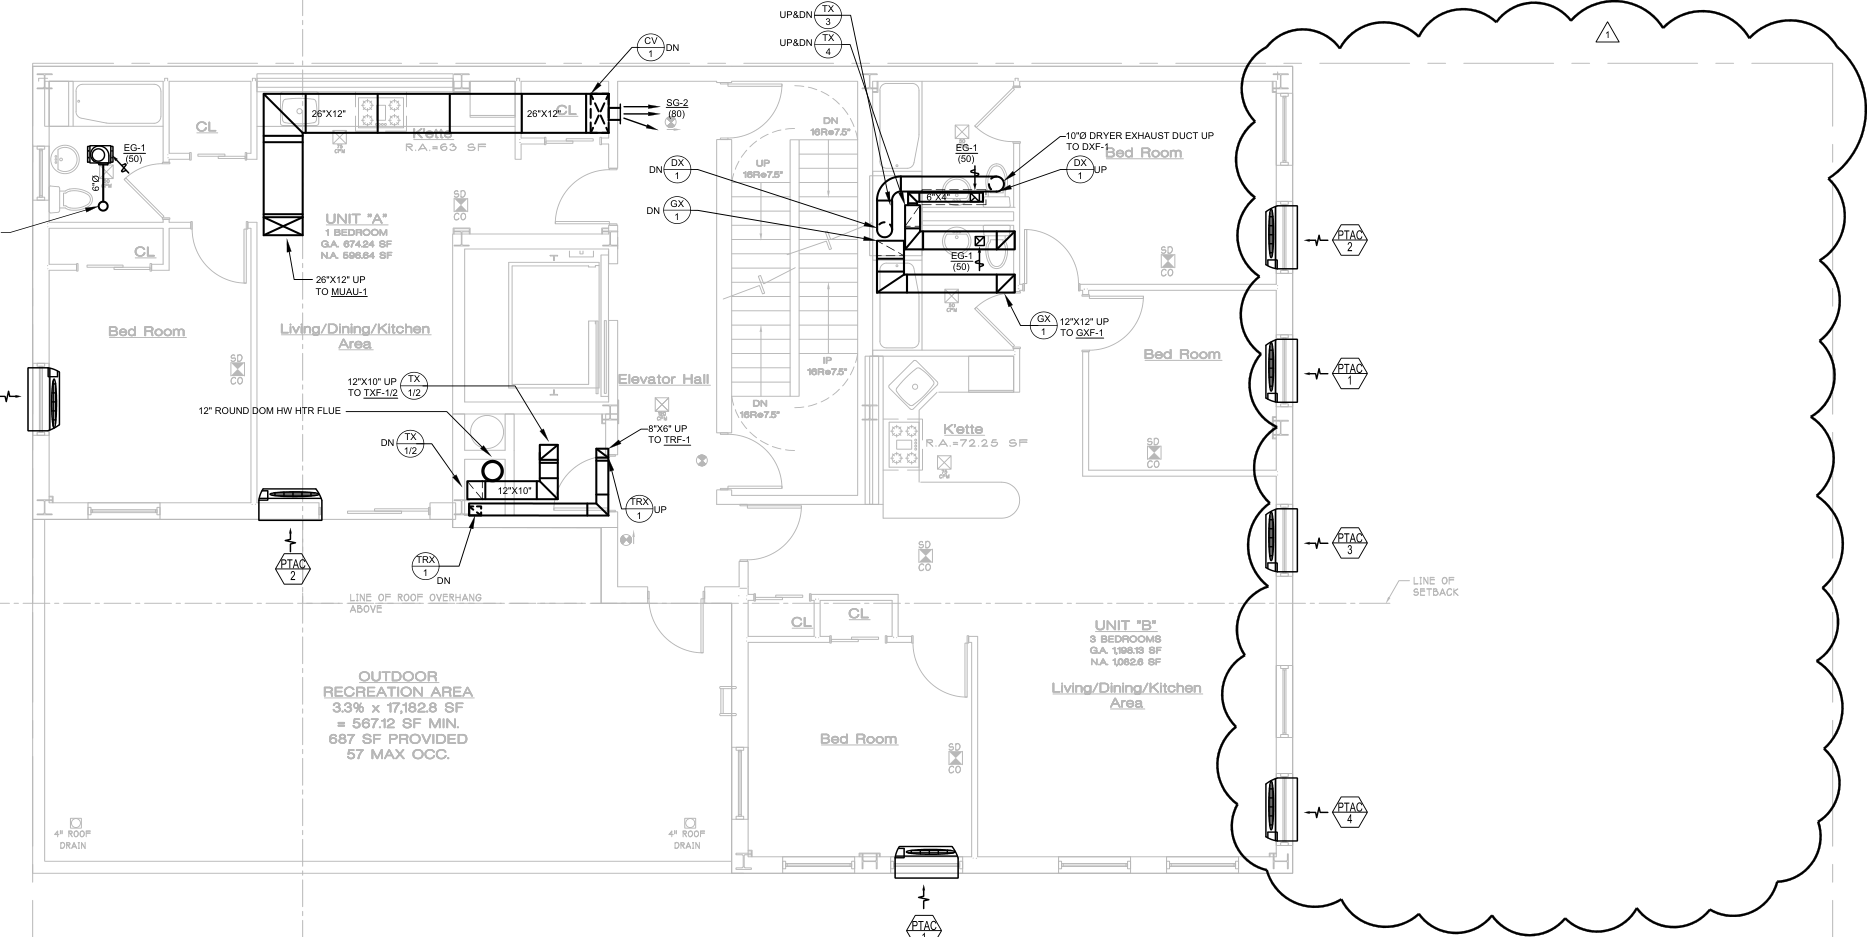

In [360]:
# Load the image using OpenCV
img = cv2.imread("/content/drive/MyDrive/*Datasets/processed_data/page_52.png")
mat_file_path = '/content/drive/MyDrive/*Datasets/ground truth data/page_52_labels.mat'

cv2_imshow(img)

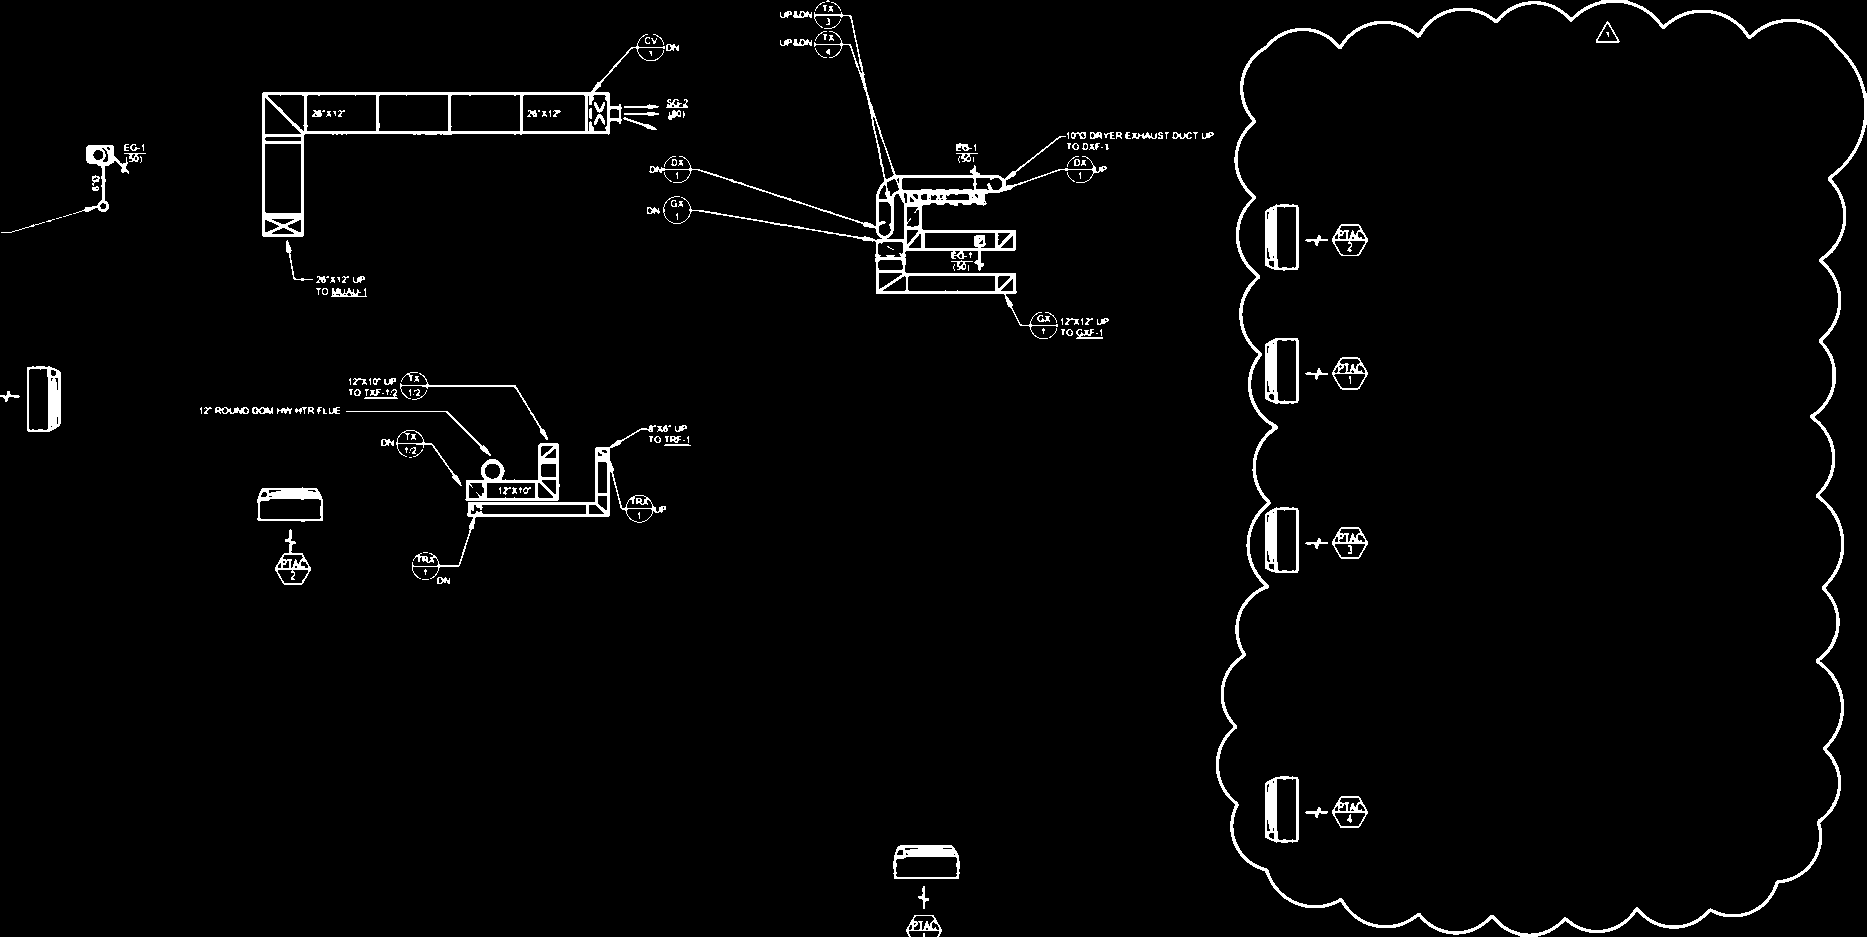

In [361]:
# Preprocess the input image
def preprocess_image(img):
    if len(img.shape) == 3:  # Convert to grayscale if it's a color image
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    _, thresh = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY_INV)
    kernel = np.ones((1, 1), np.uint8)
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)
    eroded = cv2.erode(closed, kernel, iterations=1)
    dilated = cv2.dilate(eroded, kernel, iterations=1)
    return dilated

dilated = preprocess_image(img)
cv2_imshow(dilated)

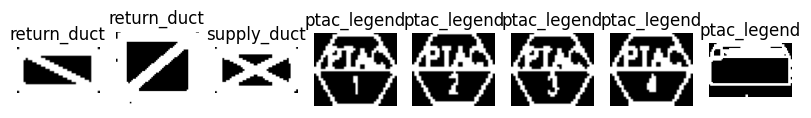

In [362]:
def preprocess_template(template_img):
    # Convert to grayscale if it's a color image
    if len(template_img.shape) == 3:
        gray = cv2.cvtColor(template_img, cv2.COLOR_BGR2GRAY)
    else:
        gray = template_img

    # Apply Gaussian blur to smooth the image
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    _, binary_img = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY_INV)
    kernel_close = np.ones((1, 1), np.uint8)
    closed = cv2.morphologyEx(binary_img, cv2.MORPH_CLOSE, kernel_close, iterations=3)
    kernel_erosion = np.ones((1, 1), np.uint8)
    eroded = cv2.erode(closed, kernel_erosion, iterations=0)
    final_img = eroded

    # Crop the image to remove whitespace
    coords = cv2.findNonZero(final_img)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        cropped = final_img[y:y+h, x:x+w]
    else:
        cropped = final_img  # If no non-zero pixels are found, use the processed image

    return cropped

# Paths for templates
template_paths = [
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/Return Air Duct - horizontal.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/Return Air Duct-v.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/Supply Air Duct - horizontal.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_1.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_2.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_3.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_4.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_horizontal.png'
]

template_names = [
    'return_duct', 'return_duct',
    'supply_duct',
    'ptac_legend', 'ptac_legend', 'ptac_legend', 'ptac_legend',
    'ptac_legend'
]

# Load and preprocess templates
templates = [preprocess_template(cv2.imread(path, 0)) for path in template_paths]

# Plot each template using matplotlib
plt.figure(figsize=(10, 5))
for i, (template, name) in enumerate(zip(templates, template_names)):
    plt.subplot(1, len(templates), i + 1)
    plt.imshow(template, cmap='gray')
    plt.title(name)
    plt.axis('off')
plt.show()

In [367]:
# Define a function to preprocess templates and extract contours at specific 90-degree angles
def preprocess_template_with_all_contours(template_img, rotation_angles=[0, 90, 180, 270]):
    processed_templates = []
    for angle in rotation_angles:
        (h, w) = template_img.shape[:2]
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated_template = cv2.warpAffine(template_img, M, (w, h))

        # Preprocess the rotated template
        gray = cv2.GaussianBlur(rotated_template, (3, 3), 0)
        _, binary_img = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)
        kernel = np.ones((1, 1), np.uint8)
        processed = cv2.morphologyEx(binary_img, cv2.MORPH_CLOSE, kernel, iterations=1)
        processed = cv2.erode(processed, kernel, iterations=1)
        processed = cv2.dilate(processed, kernel, iterations=1)

        # Crop the image to remove whitespace
        coords = cv2.findNonZero(processed)
        if coords is not None:
            x, y, w, h = cv2.boundingRect(coords)
            cropped = processed[y:y+h, x:x+w]

            # Find all contours (both internal and external)
            contours, _ = cv2.findContours(cropped, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
            if contours:
                # Combine all contours into one
                combined_contour = np.vstack(contours)
                processed_templates.append((cropped, combined_contour))  # Store template and its combined contour

    return processed_templates

# Function to count edges (vertices) of a contour
def count_contour_edges(contour, epsilon_factor=0.02):
    epsilon = epsilon_factor * cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, epsilon, True)
    return len(approx)


In [368]:
# Preprocess templates with rotations at 90-degree increments and extract all contours
all_template_variants = []
for t in templates:
    if t is not None:
        rotated_templates = preprocess_template_with_all_contours(t, rotation_angles=[0, 90, 180, 270])
        all_template_variants.append(rotated_templates)
    else:
        all_template_variants.append([])

# Define the scales and threshold for template matching
scales = [1.0, 0.95, 0.9, 0.85, 0.8]
threshold = 0.7

# Define template colors
template_colors = {
    'return_duct': (0, 0, 255),
    'supply_duct': (255, 0, 0),
    'ptac_legend': (255, 165, 0)
}

# Define template-specific thresholds
template_thresholds = {
    'return_duct': 0.7,
    'supply_duct': 0.5,
    'ptac_legend': 0.4
}

# Initialize the dictionary to store predicted bounding boxes
predicted_boxes = {
    "SupplyDuct": [],
    "ReturnDuct": [],
    "PTAC": []
}


Invariant-Template-Matching: https://github.com/cozheyuanzhangde/Invariant-TemplateMatching

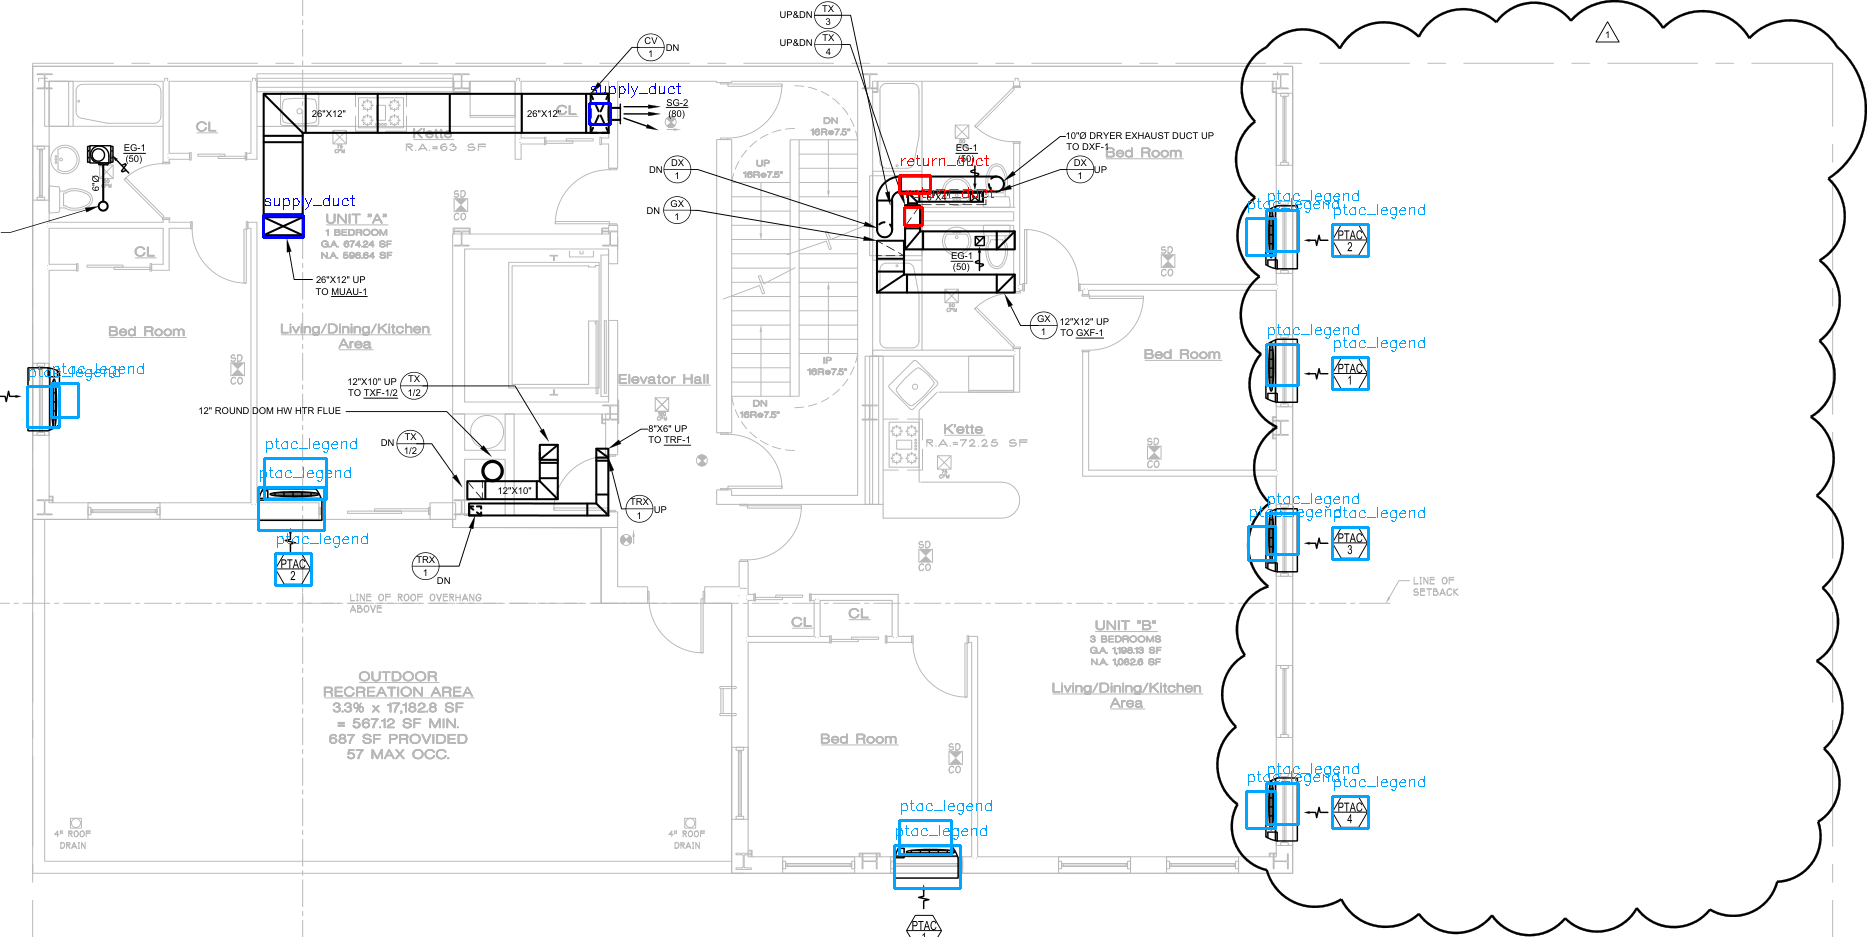


Predicted Bounding Boxes (Filtered):
SupplyDuct: [[263, 215, 40, 22], [589, 103, 21, 21]]
ReturnDuct: [[904, 207, 18, 18], [899, 175, 31, 18]]
PTAC: [[894, 845, 66, 43], [27, 386, 32, 41], [1266, 210, 32, 41], [1266, 513, 32, 41], [1266, 344, 32, 41], [1266, 783, 32, 41], [258, 487, 66, 43], [1332, 796, 36, 32], [51, 383, 27, 34], [275, 553, 36, 32], [1332, 527, 36, 32], [1246, 218, 29, 37], [1246, 791, 29, 37], [1248, 526, 27, 34], [1332, 224, 36, 32], [1332, 357, 36, 32], [899, 820, 52, 34], [264, 458, 62, 41]]


In [369]:
from collections import defaultdict

# Define Non-Maximum Suppression (NMS) with scores
def non_max_suppression_with_scores(boxes, scores, overlapThresh=0.3):
    if len(boxes) == 0:
        return []

    # Convert to float to prevent issues
    boxes = np.array(boxes, dtype=np.float32)
    scores = np.array(scores)

    # Coordinates of bounding boxes
    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = boxes[:, 2]
    y2 = boxes[:, 3]

    # Compute areas of the bounding boxes
    areas = (x2 - x1 + 1) * (y2 - y1 + 1)
    indices = np.argsort(scores)[::-1]  # Sort by scores in descending order

    picked = []
    while len(indices) > 0:
        i = indices[0]  # Index with the highest score
        picked.append(i)

        xx1 = np.maximum(x1[i], x1[indices[1:]])
        yy1 = np.maximum(y1[i], y1[indices[1:]])
        xx2 = np.minimum(x2[i], x2[indices[1:]])
        yy2 = np.minimum(y2[i], y2[indices[1:]])

        # Compute the width and height of the overlap
        w = np.maximum(0, xx2 - xx1 + 1)
        h = np.maximum(0, yy2 - yy1 + 1)

        # Compute the IoU (Intersection over Union)
        overlap = (w * h) / areas[indices[1:]]
        indices = indices[np.where(overlap <= overlapThresh)[0] + 1]

    return boxes[picked].astype("int")

# Initialize storage for unique template matches and scores
unique_template_matches = defaultdict(list)
template_scores = defaultdict(list)

# Loop through each set of template variants
for template_variants, template_name in zip(all_template_variants, template_names):
    for scaled_template, template_contour in template_variants:
        for scale in scales:
            scaled_template_resized = cv2.resize(scaled_template, (0, 0), fx=scale, fy=scale)
            (h, w) = scaled_template_resized.shape[:2]

            # Template matching
            result = cv2.matchTemplate(dilated, scaled_template_resized, cv2.TM_CCOEFF_NORMED)
            (yCoords, xCoords) = np.where(result >= threshold)

            for (x, y) in zip(xCoords, yCoords):
                score = result[y, x]  # Confidence score
                unique_template_matches[template_name].append([x, y, x + w, y + h])
                template_scores[template_name].append(score)

# Process matches for each template type
for template_name, boxes in unique_template_matches.items():
    if not boxes:
        continue

    # Convert bounding boxes and scores to numpy arrays
    boxes_np = np.array(boxes)
    scores_np = np.array(template_scores[template_name])

    # Apply Non-Maximum Suppression (NMS)
    filtered_boxes = non_max_suppression_with_scores(boxes_np, scores_np, overlapThresh=0.3)

    # Store filtered bounding boxes
    for (startX, startY, endX, endY) in filtered_boxes:
        width, height = endX - startX, endY - startY
        if template_name == "supply_duct":
            predicted_boxes["SupplyDuct"].append([startX, startY, width, height])
        elif template_name == "return_duct":
            predicted_boxes["ReturnDuct"].append([startX, startY, width, height])
        elif template_name == "ptac_legend":
            predicted_boxes["PTAC"].append([startX, startY, width, height])

        # Draw the bounding boxes
        color = template_colors.get(template_name, (0, 255, 0))
        cv2.rectangle(img, (startX, startY), (endX, endY), color, 2)
        cv2.putText(img, template_name, (startX, startY - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

# Display the final image with detected features
cv2_imshow(img)

# Debugging: Print predicted bounding boxes
print("\nPredicted Bounding Boxes (Filtered):")
for label, boxes in predicted_boxes.items():
    print(f"{label}: {boxes}")

Evaluate object detection using ground-truth-labeled image from MATLAB image labeler.

In [324]:
from scipy.io import loadmat

# Load the .mat file
mat_data = loadmat(mat_file_path)

# Inspect the keys to identify the structure
print("Keys in the .mat file:", mat_data.keys())

# Extract the struct
labels_struct = mat_data['labelsStruct']  # Adjust based on the key name

# Parse bounding boxes for each label type
def parse_bounding_boxes(bbox_array):
    """Converts MATLAB bounding boxes to Python-friendly lists."""
    if bbox_array.size == 0:
        return []  # Return empty if no bounding boxes
    if isinstance(bbox_array, np.ndarray):
        # Case 1: Directly in (N, 4) format
        if bbox_array.ndim == 2 and bbox_array.shape[1] == 4:
            return bbox_array.tolist()
        # Case 2: Single bounding box as a flat array (e.g., [x, y, width, height])
        elif bbox_array.ndim == 1 and bbox_array.size == 4:
            return [bbox_array.tolist()]
        # Case 3: Nested or irregular single bounding box
        elif bbox_array.ndim == 2 and bbox_array.shape[0] == 1 and bbox_array.shape[1] == 1:
            # Drill down into the nested array and reshape
            nested_bbox = bbox_array[0, 0]
            if nested_bbox.ndim == 1 and nested_bbox.size == 4:
                return [nested_bbox.tolist()]
            elif nested_bbox.ndim == 2 and nested_bbox.shape[1] == 4:
                return nested_bbox.tolist()
        # Case 4: Reshape flat array into (N, 4)
        try:
            return bbox_array.reshape(-1, 4).tolist()
        except ValueError:
            pass  # Fall through to empty return if reshaping fails
    return []  # Default return for unrecognized formats


# Parse ground truth bounding boxes
parsed_labels = []
for row in labels_struct:
    supply_duct, return_duct, ptac = row[0]
    parsed_labels.append({
        "SupplyDuct": parse_bounding_boxes(supply_duct),
        "ReturnDuct": parse_bounding_boxes(return_duct),
        "PTAC": parse_bounding_boxes(ptac),
    })

ground_truth_boxes = parsed_labels[0]
supply_duct_boxes = ground_truth_boxes["SupplyDuct"]
return_duct_boxes = ground_truth_boxes["ReturnDuct"]
ptac_boxes = ground_truth_boxes["PTAC"]

# Display parsed bounding boxes
print("")
print("SupplyDuct bounding boxes:", supply_duct_boxes)
print("ReturnDuct bounding boxes:", return_duct_boxes)
print("PTAC bounding boxes:", ptac_boxes)


Keys in the .mat file: dict_keys(['__header__', '__version__', '__globals__', 'labelsStruct'])

SupplyDuct bounding boxes: [[260, 216, 48, 24], [584, 88, 31, 57]]
ReturnDuct bounding boxes: [[536, 442, 29, 25], [995, 272, 26, 27], [994, 227, 27, 29]]
PTAC bounding boxes: [[1332, 215, 42, 47], [1331, 348, 42, 47], [1332, 516, 42, 52], [1331, 783, 42, 56], [1259, 774, 50, 77], [1264, 505, 41, 72], [1266, 327, 39, 87], [1261, 201, 46, 78], [890, 839, 75, 44], [269, 552, 46, 37], [254, 484, 76, 43], [23, 356, 46, 84]]


In [325]:
from shapely.geometry import box

def calculate_iou(gt_box, pred_box):
    gt = box(gt_box[0], gt_box[1], gt_box[0] + gt_box[2], gt_box[1] + gt_box[3])
    pred = box(pred_box[0], pred_box[1], pred_box[0] + pred_box[2], pred_box[1] + pred_box[3])

    intersection = gt.intersection(pred).area
    union = gt.union(pred).area

    return intersection / union if union > 0 else 0

def match_predictions(gt_boxes, pred_boxes, iou_threshold=0.5):
    """Matches predictions to ground truth boxes based on IoU."""
    matches = []
    for gt in gt_boxes:
        for pred in pred_boxes:
            iou = calculate_iou(gt, pred)
            if iou >= iou_threshold:
                matches.append((gt, pred, iou))
    return matches

def calculate_precision_recall(gt_boxes, pred_boxes, iou_threshold=0.5):
    """Calculates precision and recall for a single label type."""
    matches = match_predictions(gt_boxes, pred_boxes, iou_threshold)

    true_positives = len(matches)
    false_positives = len(pred_boxes) - true_positives
    false_negatives = len(gt_boxes) - true_positives

    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0

    return precision, recall


In [326]:
iou_threshold = 0.5  # Adjust threshold as needed
for label_type in ["SupplyDuct", "ReturnDuct", "PTAC"]:
    gt_boxes = ground_truth_boxes[label_type]
    pred_boxes = predicted_boxes[label_type]

    precision, recall = calculate_precision_recall(gt_boxes, pred_boxes, iou_threshold)
    print(f"{label_type} Evaluation:")
    print(f"  Precision: {precision:.2f}")
    print(f"  Recall: {recall:.2f}")
    print("")


SupplyDuct Evaluation:
  Precision: 0.50
  Recall: 0.50

ReturnDuct Evaluation:
  Precision: 0.00
  Recall: 0.00

PTAC Evaluation:
  Precision: 0.33
  Recall: 0.50



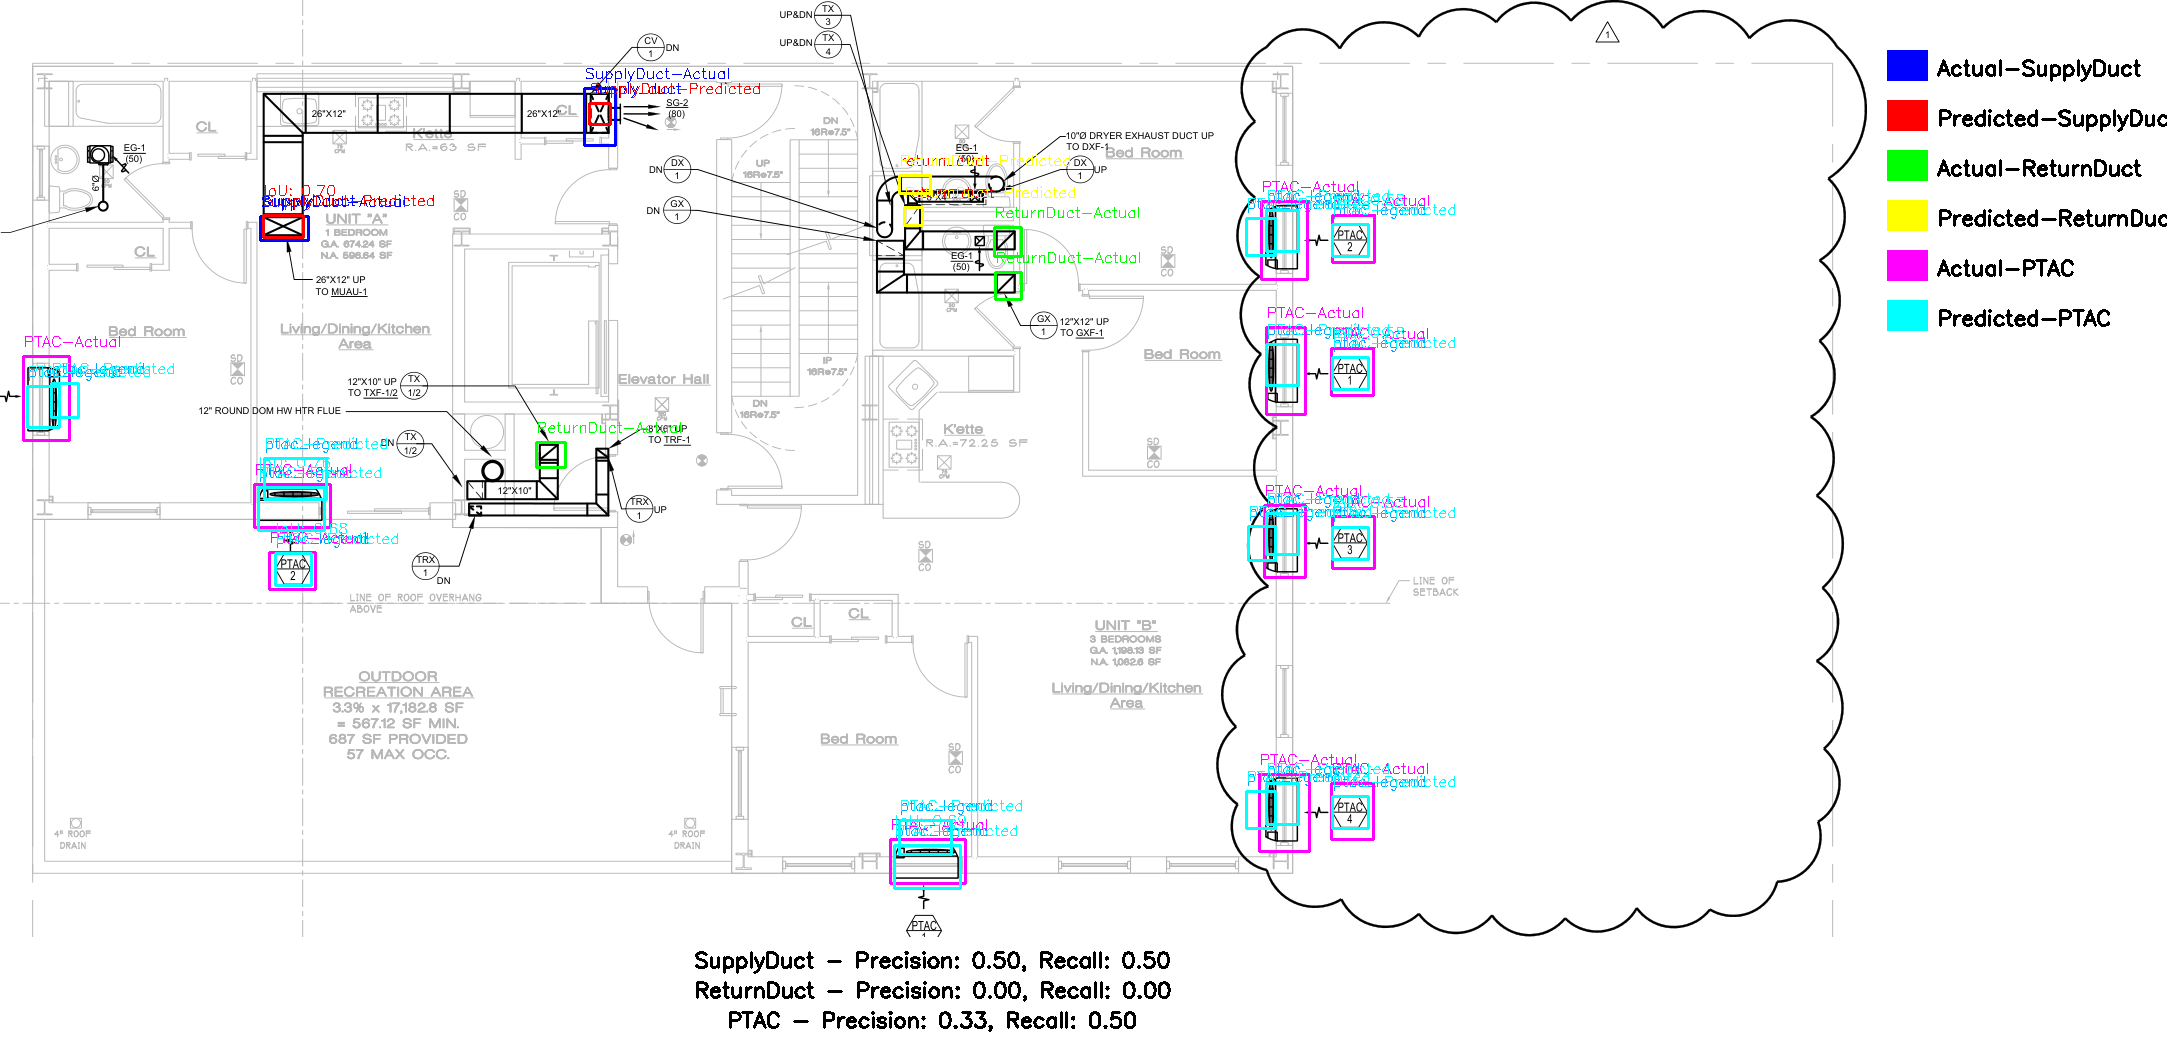

In [327]:
# Colors for visualization
colors = {
    "Actual-SupplyDuct": (255, 0, 0),  # Blue for GT
    "Predicted-SupplyDuct": (0, 0, 255),  # Red for Predictions
    "Actual-ReturnDuct": (0, 255, 0),  # Green for GT
    "Predicted-ReturnDuct": (0, 255, 255),  # Yellow for Predictions
    "Actual-PTAC": (255, 0, 255),  # Purple for GT
    "Predicted-PTAC": (255, 255, 0),  # Cyan for Predictions
}

# Function to draw bounding boxes
def draw_boxes(image, boxes, color, label):
    for box in boxes:
        x, y, w, h = box
        cv2.rectangle(image, (x, y), (x + w, y + h), color, 2)
        cv2.putText(image, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

# Function to calculate IoU and annotate
def annotate_iou(image, gt_boxes, pred_boxes, color, label, iou_threshold):
    for gt in gt_boxes:
        for pred in pred_boxes:
            iou = calculate_iou(gt, pred)
            if iou >= iou_threshold:
                cv2.putText(
                    image,
                    f"IoU: {iou:.2f}",
                    (pred[0], pred[1] - 20),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    color,
                    1,
                )

# Create a copy of the image for visualization
visualized_image = img.copy()

# Visualize bounding boxes for each label type
for label_type, gt_color, pred_color in zip(
    ["SupplyDuct", "ReturnDuct", "PTAC"],
    ["Actual-SupplyDuct", "Actual-ReturnDuct", "Actual-PTAC"],
    ["Predicted-SupplyDuct", "Predicted-ReturnDuct", "Predicted-PTAC"],
):
    gt_boxes = ground_truth_boxes[label_type]
    pred_boxes = predicted_boxes[label_type]

    # Draw GT and Predicted boxes
    draw_boxes(visualized_image, gt_boxes, colors[gt_color], label_type + "-Actual")
    draw_boxes(visualized_image, pred_boxes, colors[pred_color], label_type + "-Predicted")

    # Annotate IoU for matches
    annotate_iou(
        visualized_image, gt_boxes, pred_boxes, colors[pred_color], label_type, iou_threshold
    )

# Add space for the legend and metrics
legend_width = 300
bottom_padding = 120
canvas = np.ones(
    (visualized_image.shape[0] + bottom_padding, visualized_image.shape[1] + legend_width, 3),
    dtype=np.uint8,
) * 255
canvas[: visualized_image.shape[0], : visualized_image.shape[1]] = visualized_image

# Add legend on the right
legend_y_start = 50
legend_y_step = 50
for idx, (label, color) in enumerate(colors.items()):
    y_pos = legend_y_start + idx * legend_y_step
    cv2.rectangle(canvas, (visualized_image.shape[1] + 20, y_pos), (visualized_image.shape[1] + 60, y_pos + 30), color, -1)
    cv2.putText(canvas, label, (visualized_image.shape[1] + 70, y_pos + 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)

# Add precision and recall metrics at the bottom center
iou_threshold = 0.5
metrics_text_y = visualized_image.shape[0] + 30
for idx, label_type in enumerate(["SupplyDuct", "ReturnDuct", "PTAC"]):
    gt_boxes = ground_truth_boxes[label_type]
    pred_boxes = predicted_boxes[label_type]

    precision, recall = calculate_precision_recall(gt_boxes, pred_boxes, iou_threshold)
    label = f"{label_type} - Precision: {precision:.2f}, Recall: {recall:.2f}"
    text_size = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)[0]
    text_x = (canvas.shape[1] - legend_width - text_size[0]) // 2
    cv2.putText(
        canvas,
        label,
        (text_x, metrics_text_y + idx * 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 0, 0),
        2,
    )

# Show the visualization
cv2_imshow(canvas)